## 99. Debugging

### 0. Packages

In [2]:
# Packages
import datetime
#import folium
import geopandas as gpd
import matplotlib.pyplot as plt
import rioxarray as rxr
import xarray as xr
import glob
import contextily as ctx

### 1. Load the data

In [3]:
# File paths
file_path_tiles = r'p:\11209821-cmems-global-sdb\00_miscellaneous\AOI_polygons_world\df_boxes_world_Z10_filtered_v2.parquet'
file_path_gtsm_stations= r'p:\11209821-cmems-global-sdb\01_intertidal\02_data\02_gtsm_files\gtsm_stations_filtered_v2.parquet'
file_path_mask = r'p:\11209821-cmems-global-sdb\00_miscellaneous\Feasibility_maps\2024\gebco_2024_latminus2_merge_result.parquet'
file_path_mask_ed = r'p:\11209821-cmems-global-sdb\00_miscellaneous\Feasibility_maps\2024\gebco_2024_latminus2_merge_result_erosion_dilation.parquet'
file_path_gtsm_combined = r'p:\1230882-emodnet_hrsm\GTSMv3.0EMODnet\CMEMS_intertidal_SDB\zarr_files\gtsm_model_his_combined_v2.zarr'

In [4]:
# Read data
gdf_tiles = gpd.read_parquet(file_path_tiles)
gdf_stations = gpd.read_parquet(file_path_gtsm_stations)
gdf_mask = gpd.read_parquet(file_path_mask)
gdf_mask_ed = gpd.read_parquet(file_path_mask_ed)
ds_gtsm = xr.open_zarr(file_path_gtsm_combined)

# Convert station name to string
gdf_stations['station_name'] = gdf_stations['station_name'].astype(str)

# Make station id the index of stations
ds_gtsm = ds_gtsm.set_index(stations='station_id')

### 2. Checking tiles

In [12]:
# File path bathy
file_path_bathy = r'p:\11209821-cmems-global-sdb\01_intertidal\02_data\05_calibrated\intertidal_improved_100m_upscaled_v3\03_merged\z10_x507_y363_t2021-01-01_2022-01-01_100m.tif'

# Open bathy
da_bathy = rxr.open_rasterio(file_path_bathy)

In [19]:
# Get tile
gdf_tile = gdf_tiles[gdf_tiles['name'] == 'z10_x507_y363']
gdf_tile.head()

,station_id,station_name,station_longitude,station_latitude,bedlevel,waterlevel_mean,waterlevel_min,waterlevel_max,geometry,hat,lat,tidal_stage_percentage_mean,tidal_stage_percentage_min,tidal_stage_percentage_max,high_tide_offset,low_tide_offset,tide_spread
3718,station 03718,id_coast_glob_eur_03719 ...,-1.503801,46.2614,-27.776372,0.0077,-3.601341,2.969357,POINT (-1.50380 46.26140),3.002991,-3.602132,54.652007,0.011967,99.490791,0.509209,0.011967,99.478824


In [20]:
# Get station
gdf_station = gdf_stations[gdf_stations['station_id'] == gdf_tile['nearest_station_id'].values[0]]
gdf_station.head()

,station_id,station_name,station_longitude,station_latitude,bedlevel,waterlevel_mean,waterlevel_min,waterlevel_max,geometry,hat,lat,tidal_stage_percentage_mean,tidal_stage_percentage_min,tidal_stage_percentage_max,high_tide_offset,low_tide_offset,tide_spread
3718,station 03718,id_coast_glob_eur_03719 ...,-1.503801,46.2614,-27.776372,0.0077,-3.601341,2.969357,POINT (-1.50380 46.26140),3.002991,-3.602132,54.652007,0.011967,99.490791,0.509209,0.011967,99.478824


In [8]:
# Plot tile and station
m = folium.Map(location=[gdf_station.geometry.y.iloc[0], gdf_station.geometry.x.iloc[0]], zoom_start=10)
m = gdf_tile.explore(m=m, color='red')
m = gdf_station.explore(m=m, color='blue')
m

In [15]:
# Get GTSM data for station and period
period = slice('2021-03-22', '2021-03-30')
ds_gtsm_ss = ds_gtsm.sel(stations=gdf_station['station_id'].values[0]).sel(time=period)
print('Station id:', gdf_station['station_id'].values[0])

# Get times and waterlevels from bathymetry
times = eval(da_bathy.attrs['gtsm_times'])
waterlevels = eval(da_bathy.attrs['gtsm_water_levels'])
print('Station id:', da_bathy.attrs['gtsm_station'])

# Plot timeseries
fig, ax = plt.subplots(figsize=(15, 5))
ds_gtsm_ss['waterlevel'].plot(ax=ax)
ax.scatter(times, waterlevels, color='red', s=2, zorder=2)
ax.hlines(y=gdf_station['lat'], xmin=ds_gtsm_ss['time'].min(), xmax=ds_gtsm_ss['time'].max(), color='red')
ax.hlines(y=gdf_station['hat'], xmin=ds_gtsm_ss['time'].min(), xmax=ds_gtsm_ss['time'].max(), color='green')

#ax.hlines(y=gdf_station['bedlevel'], xmin=ds_gtsm_ss['time'].min(), xmax=ds_gtsm_ss['time'].max(), color='red')
ax.set_xlim(ds_gtsm_ss['time'].min(), ds_gtsm_ss['time'].max())

NameError: name 'gdf_station' is not defined

### Checking stations

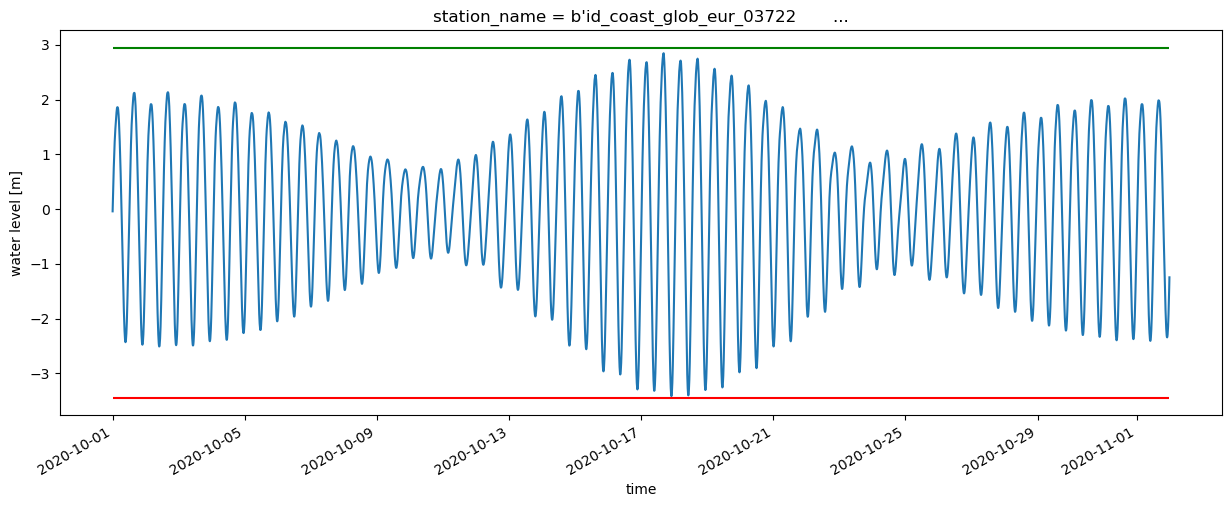

In [32]:
# Get GTSM data for station and period
station_id = 'station 03721'
period = slice('2020-10-01', '2020-11-01')
gdf_station = gdf_stations[gdf_stations['station_id'] == station_id]
ds_gtsm_ss = ds_gtsm.sel(stations=station_id).sel(time=period)

# Plot timeseries
fig, ax = plt.subplots(figsize=(15, 5))
ds_gtsm_ss['waterlevel'].plot(ax=ax)
ax.hlines(y=gdf_station['lat'], xmin=ds_gtsm_ss['time'].min(), xmax=ds_gtsm_ss['time'].max(), color='red')
ax.hlines(y=gdf_station['hat'], xmin=ds_gtsm_ss['time'].min(), xmax=ds_gtsm_ss['time'].max(), color='green')

### 2. Checking bathymetries

In [7]:
from morphopy import DataArrayList
from morphopy.process import get_gradient
from tqdm import tqdm
import glob
import os
import geopandas as gpd
import matplotlib.pyplot as plt
from resilientplotterclass import rpc

# Load bathymetries
file_path_bathys = glob.glob(r'p:\11209821-cmems-global-sdb\01_intertidal\02_data\05_calibrated\intertidal_improved_100m_upscaled_v4\03_merged\*.tif')
grids = DataArrayList()
for file_path_bathy in tqdm(file_path_bathys):
    grids.read(file_path_bathy, long_name = '_'.join(os.path.basename(file_path_bathy).split('_')[0:3]), unit='m')

# Load mask
file_path_mask = r'p:\11209821-cmems-global-sdb\00_miscellaneous\Feasibility_maps\2024\gebco_2024_latminus2_merge_result.parquet'
file_path_mask_ed = r'p:\11209821-cmems-global-sdb\00_miscellaneous\Feasibility_maps\2024\gebco_2024_latminus2_merge_result_erosion_dilation.parquet'
gdf_mask = gpd.read_parquet(file_path_mask)
gdf_mask_ed = gpd.read_parquet(file_path_mask_ed)

100%|██████████| 173/173 [00:02<00:00, 81.72it/s]


NameError: name 'gdf_mask_ed' is not defined

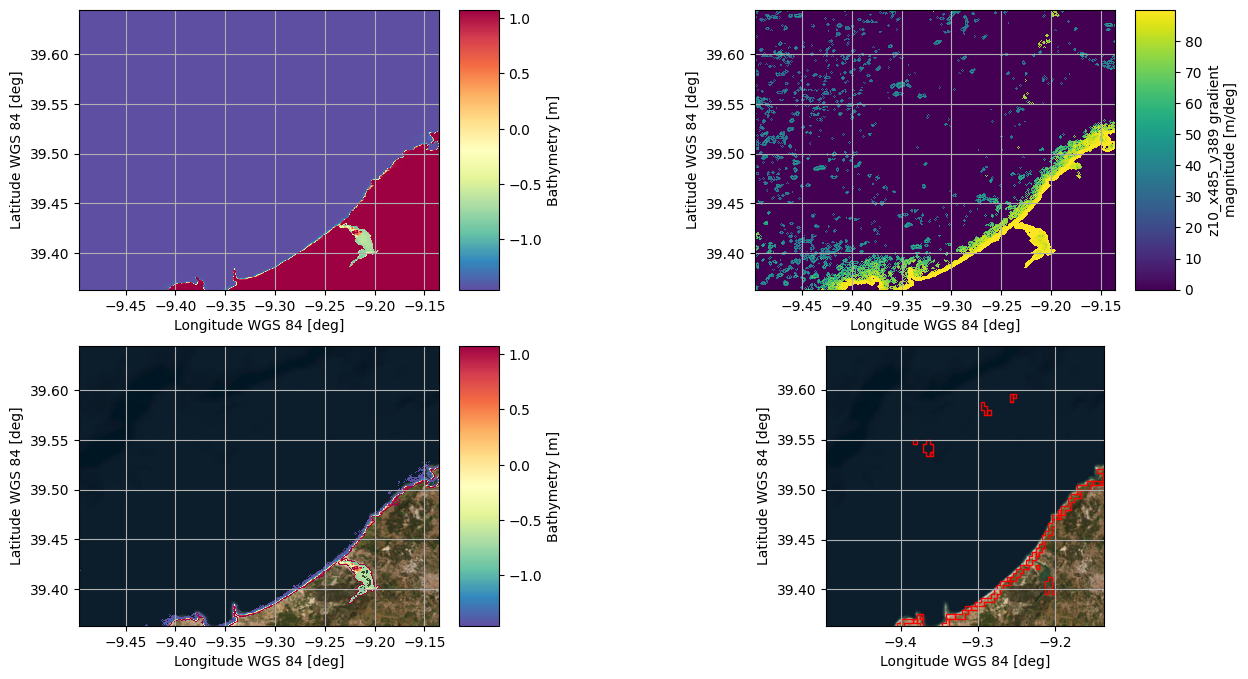

In [6]:
# Get gradient
grid = grids[0]
magnitude, _ = get_gradient(grid)
mask = magnitude.isel(band=0) > 85

fig, axs = plt.subplots(2, 2, figsize=(16, 8))
axs = axs.flatten()
rpc.imshow(grid.isel(band=0), ax=axs[0], data_type='bathymetry')
rpc.imshow(magnitude.isel(band=0), ax=axs[1], data_type='data', cmap='viridis')
rpc.imshow(grid.isel(band=0).where(mask), ax=axs[2], data_type='bathymetry')
rpc.basemap(ax=axs[2], crs=grid.crs, map_type='satellite')
axs[3].set_xlim(grid.x.min(), grid.x.max())
axs[3].set_ylim(grid.y.min(), grid.y.max())
rpc.basemap(ax=axs[3], crs=grid.crs, map_type='satellite')
gdf_mask.cx[grid.x.min():grid.x.max(), grid.y.min():grid.y.max()].plot(ax=axs[3], facecolor='none', edgecolor='red', linewidth=1)
gdf_mask_ed.cx[grid.x.min():grid.x.max(), grid.y.min():grid.y.max()].plot(ax=axs[3], facecolor='none', edgecolor='blue', linewidth=1)
fig.tight_layout()

Percentage: 0.016061777443716667
Percentage new: 0.01614231003257096
Percentage new: 0.016321271341136045
Percentage new: 0.016446544257131608
Percentage new: 0.016509180715129388
Percentage new: 0.016580765238555423
Percentage new: 0.016688142023694476
Percentage new: 0.016822363005118295
Percentage new: 0.016983428182826873
Percentage new: 0.017090804967965927
Percentage new: 0.017207129818533232
Percentage new: 0.017314506603672286
Percentage new: 0.017457675650524355
Percentage new: 0.017556104370235154
Percentage new: 0.017717169547943733
Percentage new: 0.017806650202226278
Percentage new: 0.017896130856508822
Percentage new: 0.018039299903360895
Percentage new: 0.018227209277354234
Percentage new: 0.01845985897848885
Percentage new: 0.018656716417910446
Percentage new: 0.018898314184473318
Percentage new: 0.019283080997888256
Percentage new: 0.019694692007587958
Percentage new: 0.02014209527900068
Percentage new: 0.0206879272701242
Percentage new: 0.021171122803249936
Percentage

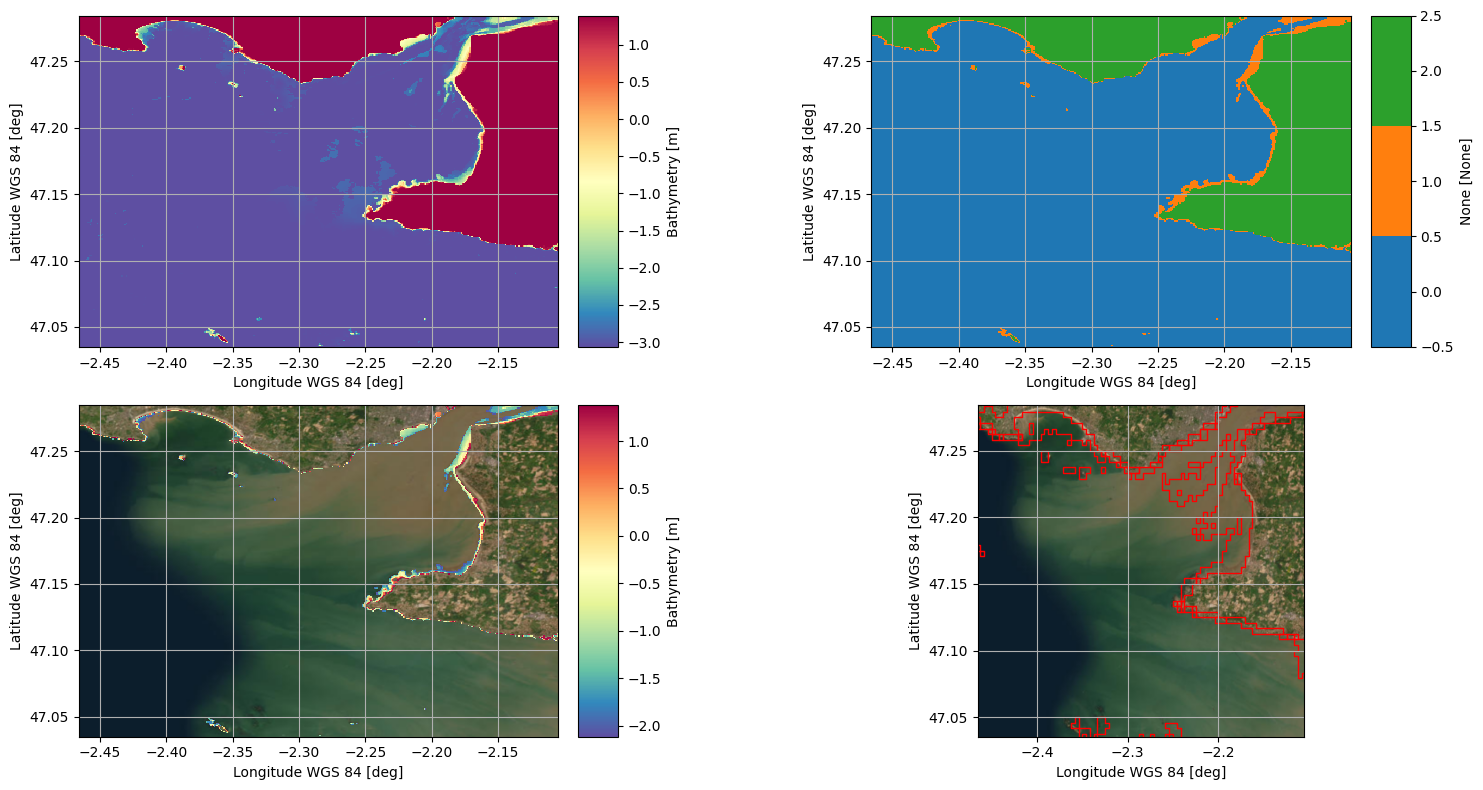

In [124]:
# Otsu thresholding 3 classes
from skimage.filters import threshold_multiotsu
import numpy as np
from morphopy.utils import createDataArray
grid = grids[5]
thresholds = threshold_multiotsu(grid.isel(band=0).values[~np.isnan(grid.isel(band=0).values)], classes=3)
classes = createDataArray(np.digitize(grid.isel(band=0).values, bins=thresholds), x=grid.x, y=grid.y, crs=grid.crs)
mask = (classes > 0) & (classes < len(thresholds))
percentage = mask.sum() / mask.size
print('Percentage:', float(percentage))

# Optimise top threshold
percentage_new = percentage
while np.abs(percentage_new - percentage) < 0.10:
    thresholds[-1] += 0.05
    classes = createDataArray(np.digitize(grid.isel(band=0).values, bins=thresholds), x=grid.x, y=grid.y, crs=grid.crs)
    mask = (classes > 0) & (classes < len(thresholds))
    percentage_new = mask.sum() / mask.size
    print('Percentage new:', float(percentage_new))
thresholds[-1] -= 0.05
classes = createDataArray(np.digitize(grid.isel(band=0).values, bins=thresholds), x=grid.x, y=grid.y, crs=grid.crs)
mask = (classes > 0) & (classes < len(thresholds))
percentage = mask.sum() / mask.size
print('Percentage:', float(percentage))

import matplotlib as mpl
fig, axs = plt.subplots(2, 2, figsize=(16, 8))
axs = axs.flatten()
rpc.imshow(grid.isel(band=0), ax=axs[0], data_type='bathymetry')
cmap = mpl.colors.ListedColormap([mpl.colormaps['tab10'](i) for i in range(len(thresholds)+1)])
rpc.imshow(classes, ax=axs[1], data_type='data', cmap=cmap, vmin=-0.5, vmax=len(thresholds)+0.5)
rpc.imshow(grid.isel(band=0).where(mask), ax=axs[2], data_type='bathymetry')
rpc.basemap(ax=axs[2], crs=grid.crs, map_type='satellite')
axs[3].set_xlim(grid.x.min(), grid.x.max())
axs[3].set_ylim(grid.y.min(), grid.y.max())
rpc.basemap(ax=axs[3], crs=grid.crs, map_type='satellite')
gdf_mask.cx[grid.x.min():grid.x.max(), grid.y.min():grid.y.max()].plot(ax=axs[3], facecolor='none', edgecolor='red', linewidth=1)
#gdf_mask_ed.cx[grid.x.min():grid.x.max(), grid.y.min():grid.y.max()].plot(ax=axs[3], facecolor='none', edgecolor='blue', linewidth=1)
fig.tight_layout()

In [30]:
grids

DataArrayList
Name Long name     z-unit xy-unit Shape           Resolution      Bounds                   CRS       Nodata Cached 
                                  (nband, ny, nx) (xres, yres)    (xmin, ymin, xmax, ymax)                         
———— ————————————— —————— ——————— ——————————————— ——————————————— ———————————————————————— ————————— —————— —————— 
0    z10_x485_y389 m      deg     (2, 313, 402)   (0.001, -0.001) (-9, 39, -9, 40)         EPSG:4326 nan    False  
1    z10_x485_y392 m      deg     (2, 317, 402)   (0.001, -0.001) (-9, 39, -9, 39)         EPSG:4326 nan    False  
2    z10_x486_y376 m      deg     (2, 298, 403)   (0.001, -0.001) (-9, 43, -9, 43)         EPSG:4326 nan    False  
3    z10_x486_y377 m      deg     (2, 299, 403)   (0.001, -0.001) (-9, 43, -9, 43)         EPSG:4326 nan    False  
4    z10_x486_y380 m      deg     (2, 302, 403)   (0.001, -0.001) (-9, 42, -9, 42)         EPSG:4326 nan    False  
5    z10_x486_y386 m      deg     (2, 310, 403)   (0.001, 

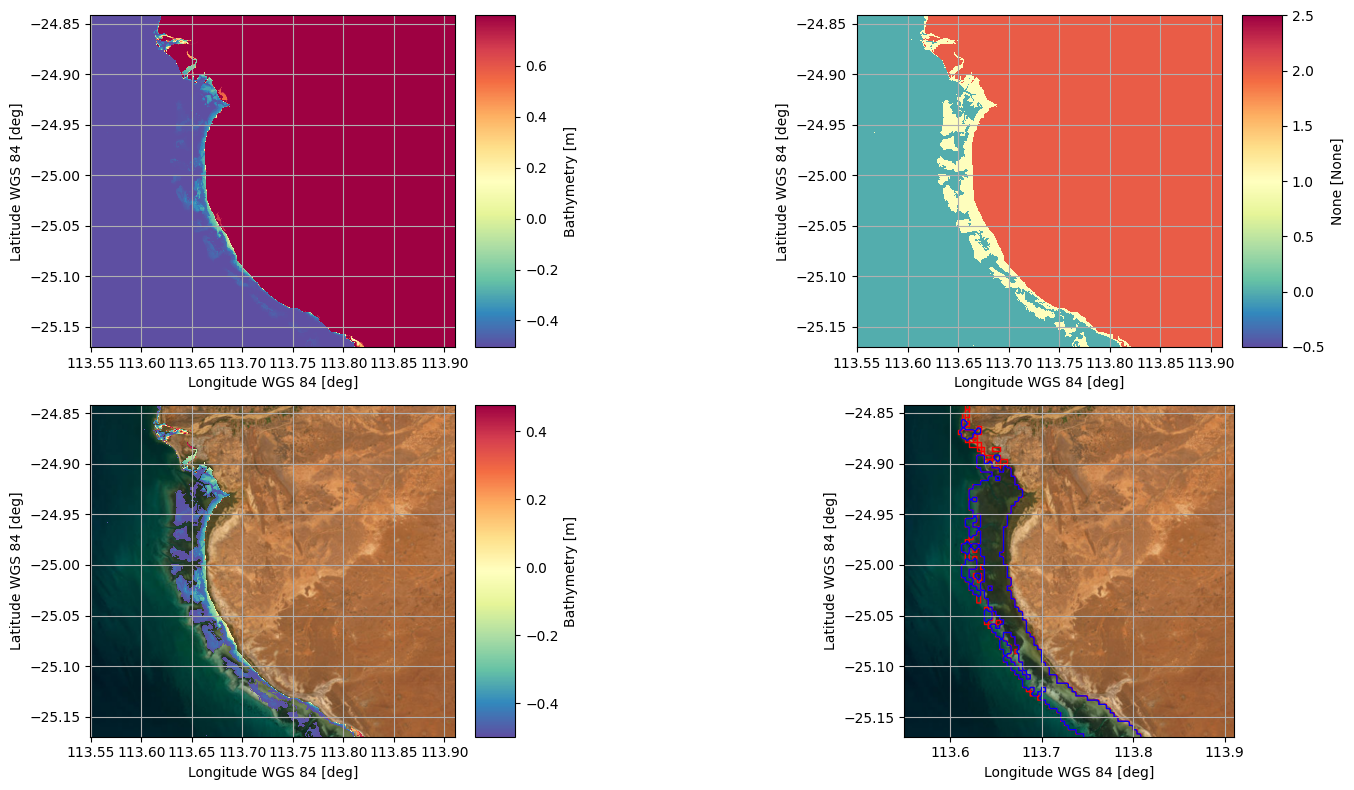

In [37]:
# Histogram thresholding 2 thresholds
import numpy as np
from morphopy.utils import createDataArray
grid = [grid for grid in grids if grid.attrs['long_name'] == 'z10_x835_y585'][0]
range = (np.nanmin(grid.isel(band=0).values), np.nanmax(grid.isel(band=0).values))
bin_size = 0.01
bins = np.arange(range[0], range[1]+bin_size, bin_size)
counts, bins = np.histogram(grid.isel(band=0).values[~np.isnan(grid.isel(band=0).values)], bins=bins)

# Sort bins according to count
bins_sorted = bins[counts.argsort()]
count_sorted = counts[counts.argsort()]

# Get cutoffs
cutoffs = [0, 0]
cutoffs[0] = bins_sorted[bins_sorted < 0][-1] + bin_size/2
cutoffs[1] = bins_sorted[bins_sorted > 0][0] - bin_size/2

# Get mask
classes = createDataArray(np.digitize(grid.isel(band=0).values, bins=cutoffs), x=grid.x, y=grid.y, crs=grid.crs)
mask = (grid.isel(band=0) > cutoffs[0]) & (grid.isel(band=0) < cutoffs[1])

fig, axs = plt.subplots(2, 2, figsize=(16, 8))
axs = axs.flatten()
rpc.imshow(grid.isel(band=0), ax=axs[0], data_type='bathymetry')
rpc.imshow(classes, ax=axs[1], data_type='data', cmap='Spectral_r', vmin=-0.5, vmax=len(cutoffs)+0.5)
rpc.imshow(grid.isel(band=0).where(mask), ax=axs[2], data_type='bathymetry')
rpc.basemap(ax=axs[2], crs=grid.crs, map_type='satellite')
axs[3].set_xlim(grid.x.min(), grid.x.max())
axs[3].set_ylim(grid.y.min(), grid.y.max())
rpc.basemap(ax=axs[3], crs=grid.crs, map_type='satellite')
gdf_mask.cx[grid.x.min():grid.x.max(), grid.y.min():grid.y.max()].plot(ax=axs[3], facecolor='none', edgecolor='red', linewidth=1)
gdf_mask_ed.cx[grid.x.min():grid.x.max(), grid.y.min():grid.y.max()].plot(ax=axs[3], facecolor='none', edgecolor='blue', linewidth=1)
fig.tight_layout()

In [ ]:
# File path bathy
file_path_bathys = glob.glob(r'p:\11209821-cmems-global-sdb\01_intertidal\02_data\05_calibrated\intertidal_improved_100m_upscaled_v3\03_merged\*.tif')
file_path_bathy = file_path_bathys[12] # 12

# Open bathy
da_bathy = rxr.open_rasterio(file_path_bathy)

# Get
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs = axs.flatten()
out = da_bathy.isel(band=0).plot.hist(bins=100, ax=axs[0])
count = out[0]
bins = out[1]

# Get binsize
binsize =  bins[1] - bins[0]

# Sort bins according to count
bins_sorted = bins[count.argsort()]
count_sorted = count[count.argsort()]

# Get largest bin below 0
bins_below_0 = bins_sorted[bins_sorted < 0]
cutoffs = [0, 0]
cutoffs[0] = bins_below_0[-1] + binsize

# Get largest bin above 0
bins_above_0 = bins_sorted[bins_sorted > 0]
cutoffs[1] = bins_above_0[0] - binsize

print(cutoffs)

da_bathy2 = da_bathy.where((da_bathy.isel(band=0) > cutoffs[0]) & (da_bathy.isel(band=0) < cutoffs[1]))
da_bathy2.isel(band=0).plot(ax=axs[1], cmap='Spectral_r')
da_bathy2.isel(band=1).plot(ax=axs[2])
ctx.add_basemap(ax=axs[1], crs=da_bathy2.rio.crs, source=ctx.providers.Esri.WorldImagery, attribution=False)
ctx.add_basemap(ax=axs[2], crs=da_bathy2.rio.crs, source=ctx.providers.Esri.WorldImagery, attribution=False)
fig.tight_layout()